# Supervised Learning from Scratch: Regression, Classification & the Bias-Variance Tradeoff

An interactive walkthrough of linear regression, polynomial regression, logistic regression, 
overfitting/underfitting, and regularization — implemented from scratch and compared against 
scikit-learn, with live widgets so you can build intuition, not just read code.

**How to use this notebook:** Run all cells top to bottom. Sliders and dropdowns are interactive — 
move them and watch the plots update live.

## Table of Contents
1. [Setup](#part0)
2. [Linear Regression](#part1)
3. [Polynomial Regression, Underfitting & Overfitting](#part2)
4. [Regularization (Ridge & Lasso)](#part3)
5. [Logistic Regression](#part4)
6. [Wrap-up & Decision Quiz](#part5)

<a id="part0"></a>
## Part 0: Setup

We'll use numpy for the from-scratch math, sklearn for comparisons and real datasets, 
and ipywidgets for interactivity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, load_breast_cancer, make_blobs
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, confusion_matrix, precision_score, 
                              recall_score, accuracy_score, roc_curve, auc)

import ipywidgets as widgets
from ipywidgets import interact

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (9, 5)
np.random.seed(42)

A few reusable functions we'll call throughout the notebook: MSE calculation, 
and adding an intercept (bias) column to a feature matrix for manual gradient descent.

In [2]:
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def add_intercept(X):
    X = np.atleast_2d(X)
    if X.shape[0] == 1 and X.shape[1] != 1:
        X = X.T
    return np.c_[np.ones((X.shape[0], 1)), X]

<a id="part1"></a>
## Part 1: Linear Regression

### The idea
We want to find a line (or hyperplane) that best predicts a continuous target from input features.

**Hypothesis:**  
$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

**Cost function (Mean Squared Error):**  
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

**Gradient Descent** minimizes this by repeatedly moving each parameter in the direction 
that reduces the cost — like a ball rolling downhill toward the lowest point.

$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

where $\alpha$ is the learning rate: too small and it crawls, too large and it can overshoot 
or diverge entirely. We'll see this live in the widget below.

### Dataset: California Housing

We'll start with a single feature — median income — against median house value, 
so the relationship is easy to visualize in 2D before we extend to multiple features later.

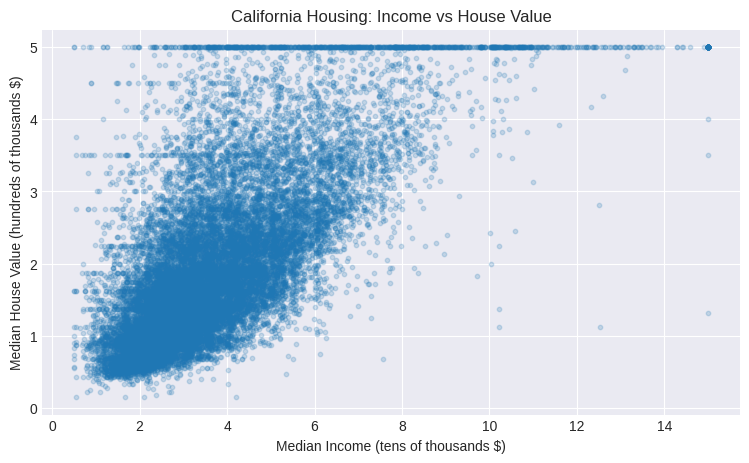

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

X_simple = df[['MedInc']].values
y_simple = df['MedHouseVal'].values

plt.scatter(X_simple, y_simple, alpha=0.2, s=10)
plt.xlabel('Median Income (tens of thousands $)')
plt.ylabel('Median House Value (hundreds of thousands $)')
plt.title('California Housing: Income vs House Value')
plt.show()

### Implementing Gradient Descent from Scratch

We scale features first (zero mean, unit variance) — gradient descent converges much faster 
and more reliably on scaled features, since unscaled features with very different ranges 
distort the shape of the cost surface. The function below returns the learned parameters, 
the cost at every iteration (so we can plot convergence), and the scaling stats needed to 
map back to the original feature space.

In [4]:
def gradient_descent(X, y, alpha=0.01, n_iters=1000):
    mu, sigma = X.mean(axis=0), X.std(axis=0)
    X_scaled = (X - mu) / sigma
    X_b = add_intercept(X_scaled)
    m, n = X_b.shape
    theta = np.zeros(n)
    cost_history = []

    for i in range(n_iters):
        y_pred = X_b @ theta
        error = y_pred - y
        gradient = (1/m) * (X_b.T @ error)
        theta -= alpha * gradient
        cost_history.append(compute_mse(y, y_pred) / 2)

    return theta, cost_history, mu, sigma

theta, cost_history, mu, sigma = gradient_descent(X_simple, y_simple, alpha=0.1, n_iters=500)

### Interactive: Gradient Descent Explorer

Adjust the learning rate and number of iterations and watch two things happen together: 
the fitted line moving toward the data, and the cost curve dropping (or, if the learning 
rate is too high, spiking or oscillating instead of converging).

**Try it:** push the learning rate close to its upper limit and watch the cost curve — 
that's what divergence looks like. Then set it very low and see how many iterations 
it takes to get anywhere close to a good fit.

In [5]:
def plot_gd(alpha=0.1, n_iters=100):
    theta, cost_history, mu, sigma = gradient_descent(X_simple, y_simple, alpha=alpha, n_iters=n_iters)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_plot = np.linspace(X_simple.min(), X_simple.max(), 100)
    x_norm = (x_plot - mu[0]) / sigma[0]
    y_line = theta[0] + theta[1] * x_norm

    axes[0].scatter(X_simple, y_simple, alpha=0.15, s=10)
    axes[0].plot(x_plot, y_line, color='red', linewidth=2)
    axes[0].set_title(f'Fit after {n_iters} iterations (α={alpha:.3f})')
    axes[0].set_xlabel('Median Income')
    axes[0].set_ylabel('House Value')

    axes[1].plot(cost_history, color='darkorange')
    axes[1].set_title('Cost vs Iteration')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Cost (MSE/2)')
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

interact(plot_gd,
         alpha=widgets.FloatLogSlider(value=0.1, base=10, min=-3, max=0.3, step=0.1, description='Learning rate α'),
         n_iters=widgets.IntSlider(value=100, min=1, max=1000, step=10, description='Iterations'));

interactive(children=(FloatLogSlider(value=0.1, description='Learning rate α', max=0.3, min=-3.0), IntSlider(v…

### Comparing with scikit-learn

We fit sklearn's `LinearRegression` on the same (unscaled) data. Note that our from-scratch 
`theta` lives in *scaled* feature space, so the raw parameter values won't match sklearn's 
directly — but the predictions and error should agree closely, which is the real check 
that our implementation is correct.

In [6]:
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_simple, y_simple)

X_norm = (X_simple.flatten() - mu[0]) / sigma[0]
y_pred_scratch = theta[0] + theta[1] * X_norm
y_pred_sklearn = lr_sklearn.predict(X_simple)

comparison = pd.DataFrame({
    'Model': ['From Scratch', 'sklearn'],
    'MSE': [compute_mse(y_simple, y_pred_scratch), compute_mse(y_simple, y_pred_sklearn)]
})
comparison

,Model,MSE
0,From Scratch,0.701131
1,sklearn,0.701131


<a id="part2"></a>
## Part 2: Polynomial Regression, Underfitting & Overfitting

### The idea

Polynomial regression fits curves instead of straight lines — but it's important to realize 
it's still *linear regression*. We're not changing the algorithm; we're transforming the 
features. Instead of fitting $y = \theta_0 + \theta_1 x$, we fit:

$$\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \dots + \theta_d x^d$$

This is still linear *in the parameters* $\theta$, which is why the same cost function and 
the same sklearn `LinearRegression` class can be reused — we just hand it extra columns 
($x^2$, $x^3$, ...) instead of writing a new algorithm.

### Underfitting vs. Overfitting

- **Underfitting**: the model is too simple to capture the pattern in the data. Both training 
  and validation error are high.
- **Good fit**: the model captures the real pattern without chasing noise. Training and 
  validation error are both low and close to each other.
- **Overfitting**: the model is complex enough to memorize noise in the training data. 
  Training error keeps dropping, but validation error rises — the model stops generalizing.

The polynomial degree is a direct knob for this tradeoff, which makes it a great way to see 
the concept rather than just define it.

### Dataset: Synthetic Sine Wave

For this section we use a synthetic dataset instead of a real one — deliberately. Because we 
generate the data ourselves, we know the *true* underlying function ($y = \sin(x)$), so we can 
visually compare what the model learns against what's actually true, not just against noisy 
points. Real datasets never give you that ground truth.

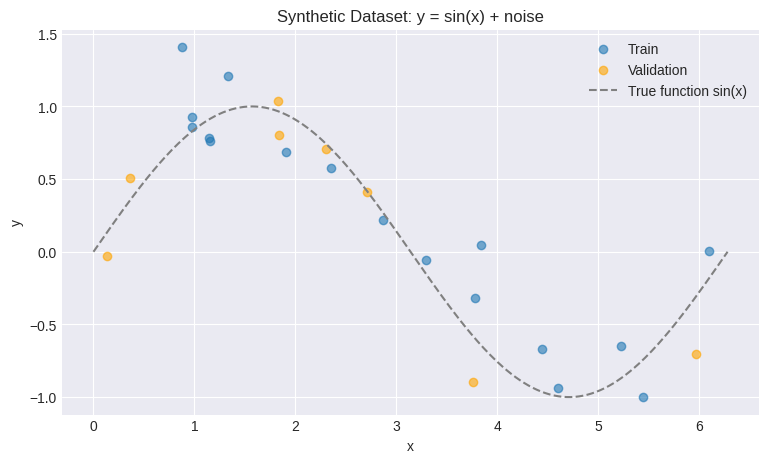

In [7]:
np.random.seed(42)
n_samples = 25  # fewer points makes overfitting much more visible

X_poly = np.sort(np.random.uniform(0, 2 * np.pi, n_samples))
y_true_fn = np.sin(X_poly)
y_poly = y_true_fn + np.random.normal(0, 0.25, n_samples)  # slightly more noise too

X_poly_train, X_poly_val, y_poly_train, y_poly_val = train_test_split(
    X_poly, y_poly, test_size=0.3, random_state=42
)

x_plot_smooth = np.linspace(0, 2 * np.pi, 300)
y_plot_smooth = np.sin(x_plot_smooth)

plt.scatter(X_poly_train, y_poly_train, label='Train', alpha=0.6)
plt.scatter(X_poly_val, y_poly_val, label='Validation', alpha=0.6, color='orange')
plt.plot(x_plot_smooth, y_plot_smooth, '--', color='gray', label='True function sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Dataset: y = sin(x) + noise')
plt.legend()
plt.show()

### Interactive: Polynomial Degree Explorer

Move the degree slider from 1 to 15 and watch three things at once: the fitted curve, and 
the train/validation error printed below it.

**Try it:**
- **Degree 1**: a straight line — too simple to follow the curve. This is underfitting.
- **Degree 3–5**: the fit tracks the sine wave closely without chasing individual noisy points.
- **Degree 12+**: the curve starts bending wildly to pass through training points exactly, 
  especially near the edges. This is overfitting — training error is very low, but the curve 
  no longer resembles the true function.

In [8]:
def plot_poly_fit(degree=1):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_poly_train.reshape(-1, 1))
    X_val_poly = poly.transform(X_poly_val.reshape(-1, 1))

    model = LinearRegression()
    model.fit(X_train_poly, y_poly_train)

    train_pred = model.predict(X_train_poly)
    val_pred = model.predict(X_val_poly)
    train_mse = compute_mse(y_poly_train, train_pred)
    val_mse = compute_mse(y_poly_val, val_pred)

    x_smooth_poly = poly.transform(x_plot_smooth.reshape(-1, 1))
    y_smooth_pred = model.predict(x_smooth_poly)

    plt.figure(figsize=(9, 5))
    plt.scatter(X_poly_train, y_poly_train, label='Train', alpha=0.6)
    plt.scatter(X_poly_val, y_poly_val, label='Validation', alpha=0.6, color='orange')
    plt.plot(x_plot_smooth, y_plot_smooth, '--', color='gray', label='True function')
    plt.plot(x_plot_smooth, y_smooth_pred, color='red', linewidth=2, label=f'Degree {degree} fit')
    plt.ylim(-2, 2)
    plt.legend()
    plt.title(f'Degree {degree} | Train MSE: {train_mse:.4f} | Val MSE: {val_mse:.4f}')
    plt.show()

interact(plot_poly_fit, degree=widgets.IntSlider(value=1, min=1, max=15, step=1, description='Degree'));

interactive(children=(IntSlider(value=1, description='Degree', max=15, min=1), Output()), _dom_classes=('widge…

### The Validation Curve

Instead of checking one degree at a time, we can plot training and validation error across 
*all* degrees at once. This produces the classic pattern behind the bias-variance tradeoff: 
training error keeps falling as the model gets more flexible, but validation error falls, 
bottoms out, then rises again once the model starts overfitting. The lowest point on the 
validation curve marks the best tradeoff — not the most complex model, and not the simplest.

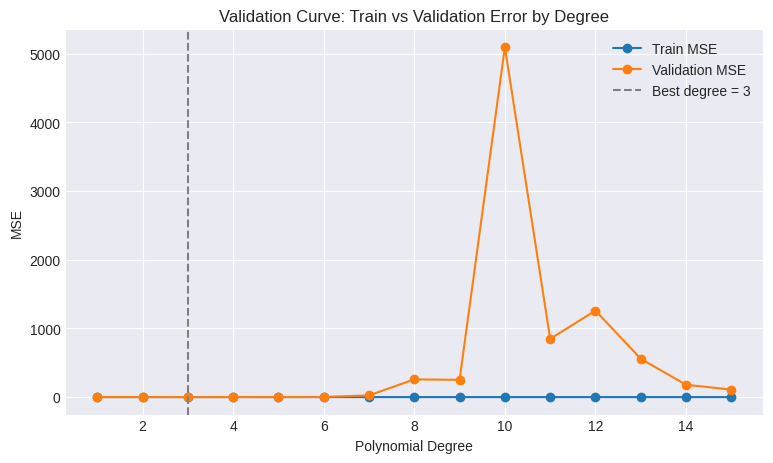

In [9]:
degrees = range(1, 16)
train_errors, val_errors = [], []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_poly_train.reshape(-1, 1))
    X_val_poly = poly.transform(X_poly_val.reshape(-1, 1))

    model = LinearRegression()
    model.fit(X_train_poly, y_poly_train)

    train_errors.append(compute_mse(y_poly_train, model.predict(X_train_poly)))
    val_errors.append(compute_mse(y_poly_val, model.predict(X_val_poly)))

best_degree = degrees[np.argmin(val_errors)]

plt.plot(degrees, train_errors, marker='o', label='Train MSE')
plt.plot(degrees, val_errors, marker='o', label='Validation MSE')
plt.axvline(best_degree, linestyle='--', color='gray', label=f'Best degree = {best_degree}')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Validation Curve: Train vs Validation Error by Degree')
plt.legend()
plt.show()

### Quick Check: Diagnose the Fit

Given a degree and its train/validation error, decide: is this underfitting, a good fit, or 
overfitting? Pick an answer from the dropdown, then run the cell to reveal the actual diagnosis 
based on the gap between train and validation error.

In [10]:
def diagnose_fit(degree=1, your_guess='Good fit'):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_poly_train.reshape(-1, 1))
    X_val_poly = poly.transform(X_poly_val.reshape(-1, 1))

    model = LinearRegression()
    model.fit(X_train_poly, y_poly_train)

    train_mse = compute_mse(y_poly_train, model.predict(X_train_poly))
    val_mse = compute_mse(y_poly_val, model.predict(X_val_poly))
    gap = val_mse - train_mse

    if train_mse > 0.15:
        actual = 'Underfitting'
    elif gap > 0.15:
        actual = 'Overfitting'
    else:
        actual = 'Good fit'

    result = pd.DataFrame({
        'Metric': ['Train MSE', 'Validation MSE', 'Your guess', 'Actual diagnosis', 'Correct?'],
        'Value': [f'{train_mse:.4f}', f'{val_mse:.4f}', your_guess, actual, your_guess == actual]
    })
    display(result)

interact(diagnose_fit,
         degree=widgets.IntSlider(value=1, min=1, max=15, step=1, description='Degree'),
         your_guess=widgets.Dropdown(options=['Underfitting', 'Good fit', 'Overfitting'], description='Your guess'));

interactive(children=(IntSlider(value=1, description='Degree', max=15, min=1), Dropdown(description='Your gues…

> **Misconception check:** "Polynomial regression is a different algorithm from linear regression."  
> False. We used `LinearRegression` for every fit above — the only thing that changed was the 
> input features (`PolynomialFeatures`). The model is still finding a straight-line relationship; 
> it's just a straight line in a higher-dimensional feature space ($x, x^2, x^3, ...$), which 
> looks curved when projected back onto the original single-feature plot.

<a id="part3"></a>
## Part 3: Regularization (Ridge & Lasso)

### The idea

In Part 2, the degree-12+ polynomial overfit by using large, wildly swinging coefficients to 
chase individual noisy points. Regularization fights this directly: it adds a penalty to the 
cost function based on the *size* of the coefficients, discouraging the model from relying too 
heavily on any one feature.

**Ridge (L2 penalty):**
$$J(\theta) = \text{MSE} + \lambda \sum_{j=1}^{n} \theta_j^2$$

**Lasso (L1 penalty):**
$$J(\theta) = \text{MSE} + \lambda \sum_{j=1}^{n} |\theta_j|$$

$\lambda$ (often called `alpha` in sklearn) controls the strength of the penalty. At 
$\lambda = 0$, both reduce to ordinary linear regression. As $\lambda$ grows, coefficients 
shrink toward zero.

**The key difference:** Ridge shrinks all coefficients smoothly but rarely to exactly zero. 
Lasso can zero out coefficients entirely — effectively performing feature selection by 
deciding some features don't matter at all. This is a geometric consequence of the L1 penalty's 
"diamond-shaped" constraint region having corners on the axes, versus L2's smooth circular one.

### Bias-variance tradeoff, revisited

Regularization trades a small increase in bias (the model can no longer fit the training data 
perfectly) for a large reduction in variance (the model is far less sensitive to noise). This 
is the same tradeoff we saw in Part 2's validation curve — regularization is just a second knob 
for controlling it, alongside model complexity.

### The Villain, Revisited

We bring back the degree-12 polynomial from Part 2 — the one that overfit badly — and apply 
Ridge and Lasso to it. Watch the same curve that was oscillating wildly settle down as the 
penalty strength increases.

In [11]:
FIXED_DEGREE = 12

poly_fixed = PolynomialFeatures(degree=FIXED_DEGREE)
X_train_poly_fixed = poly_fixed.fit_transform(X_poly_train.reshape(-1, 1))
X_val_poly_fixed = poly_fixed.transform(X_poly_val.reshape(-1, 1))
x_smooth_poly_fixed = poly_fixed.transform(x_plot_smooth.reshape(-1, 1))

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly_fixed)
X_val_poly_scaled = scaler.transform(X_val_poly_fixed)
x_smooth_poly_scaled = scaler.transform(x_smooth_poly_fixed)

### Interactive: Regularization Strength Explorer

Choose Ridge or Lasso and move the alpha (λ) slider. At α=0 you'll see the same wild degree-12 
overfit from Part 2. As α increases, the curve smooths out. Push it too far, though, and the 
model underfits again — regularization is a tradeoff, not a free lunch.

The bar chart on the right shows coefficient magnitudes. Watch how Ridge shrinks them all 
together, while Lasso drives many of them to exactly zero.

In [12]:
def plot_regularization(model_type='Ridge', alpha=0.01):
    if model_type == 'Ridge':
        model = Ridge(alpha=alpha)
    else:
        model = Lasso(alpha=alpha, max_iter=50000, tol=1e-3)

    model.fit(X_train_poly_scaled, y_poly_train)

    train_pred = model.predict(X_train_poly_scaled)
    val_pred = model.predict(X_val_poly_scaled)
    train_mse = compute_mse(y_poly_train, train_pred)
    val_mse = compute_mse(y_poly_val, val_pred)
    y_smooth_pred = model.predict(x_smooth_poly_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(X_poly_train, y_poly_train, label='Train', alpha=0.6)
    axes[0].scatter(X_poly_val, y_poly_val, label='Validation', alpha=0.6, color='orange')
    axes[0].plot(x_plot_smooth, y_plot_smooth, '--', color='gray', label='True function')
    axes[0].plot(x_plot_smooth, y_smooth_pred, color='red', linewidth=2, label=f'{model_type} fit')
    axes[0].set_ylim(-2, 2)
    axes[0].legend()
    axes[0].set_title(f'{model_type} (α={alpha:.4f}) | Train MSE: {train_mse:.4f} | Val MSE: {val_mse:.4f}')

    axes[1].bar(range(len(model.coef_)), np.abs(model.coef_), color='teal')
    axes[1].set_title('Coefficient Magnitudes')
    axes[1].set_xlabel('Coefficient index (degree)')
    axes[1].set_ylabel('|θ|')

    plt.tight_layout()
    plt.show()

interact(plot_regularization,
         model_type=widgets.Dropdown(options=['Ridge', 'Lasso'], description='Model'),
         alpha=widgets.FloatLogSlider(value=0.01, base=10, min=-4, max=1, step=0.1, description='α (λ)'));

interactive(children=(Dropdown(description='Model', options=('Ridge', 'Lasso'), value='Ridge'), FloatLogSlider…

### Ridge vs. Lasso, Side by Side

At a fixed, moderate α, compare the coefficient patterns directly. Count how many coefficients 
Lasso pushes to exactly zero versus Ridge — this is Lasso performing automatic feature selection.

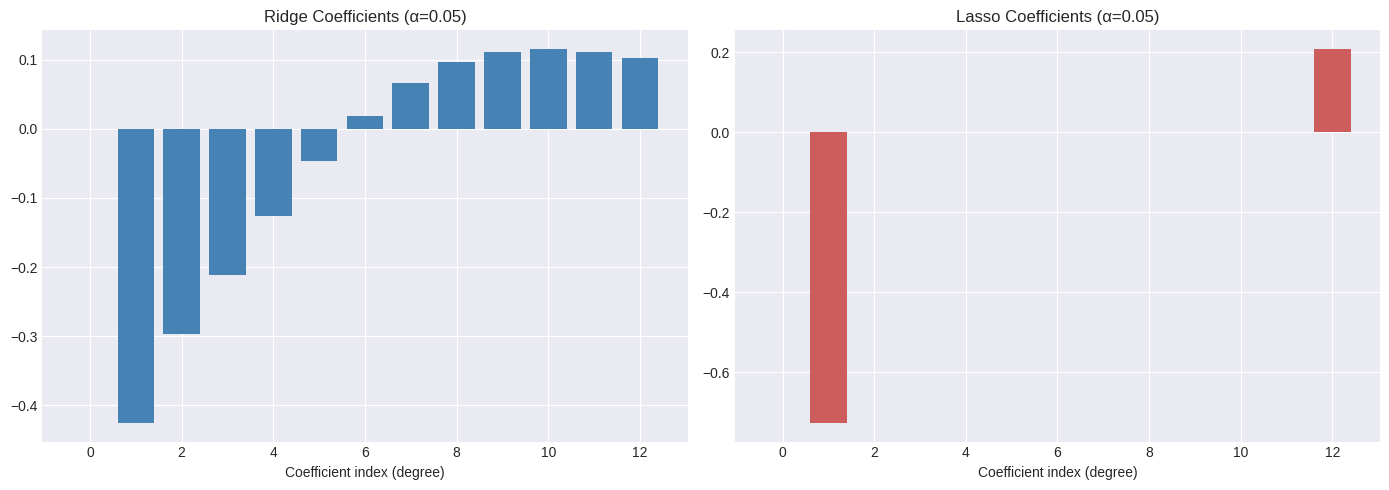

,Model,Coefficients ≈ 0,Total coefficients
0,Ridge,1,13
1,Lasso,11,13


In [13]:
FIXED_ALPHA = 0.05

ridge_model = Ridge(alpha=FIXED_ALPHA).fit(X_train_poly_scaled, y_poly_train)
lasso_model = Lasso(alpha=FIXED_ALPHA, max_iter=50000, tol=1e-3).fit(X_train_poly_scaled, y_poly_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(ridge_model.coef_)), ridge_model.coef_, color='steelblue')
axes[0].set_title(f'Ridge Coefficients (α={FIXED_ALPHA})')
axes[0].set_xlabel('Coefficient index (degree)')

axes[1].bar(range(len(lasso_model.coef_)), lasso_model.coef_, color='indianred')
axes[1].set_title(f'Lasso Coefficients (α={FIXED_ALPHA})')
axes[1].set_xlabel('Coefficient index (degree)')

plt.tight_layout()
plt.show()

n_zero_ridge = np.sum(np.abs(ridge_model.coef_) < 1e-6)
n_zero_lasso = np.sum(np.abs(lasso_model.coef_) < 1e-6)

summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso'],
    'Coefficients ≈ 0': [n_zero_ridge, n_zero_lasso],
    'Total coefficients': [len(ridge_model.coef_), len(lasso_model.coef_)]
})
summary

> **Misconception check:** "Regularization always improves the model."  
> False. Regularization reduces variance (overfitting) at the cost of some bias. At α=0 
> we're back to the original overfit model; push α too high and the model underfits, just 
> like a low-degree polynomial did in Part 2. The goal isn't maximum regularization — it's 
> finding the α that minimizes validation error, the same principle as choosing the best 
> polynomial degree.

<a id="part4"></a>
## Part 4: Logistic Regression

### Why not just use linear regression for classification?

If we tried fitting a straight line to predict a 0/1 class label, two problems appear: the 
line can predict values below 0 or above 1 (meaningless for a probability), and it's very 
sensitive to outliers pulling the whole line in one direction. We need a function that squashes 
any input into the range (0, 1).

### The sigmoid function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

We compute a linear combination of features, $z = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$, 
then pass it through the sigmoid to get a probability:

$$\hat{y} = \sigma(z) = P(y=1 \mid x)$$

We classify as class 1 if $\hat{y} \geq \text{threshold}$ (0.5 by default), else class 0.

### Cost function: Log Loss

Mean squared error doesn't work well here — it produces a non-convex cost surface for this 
model, making gradient descent unreliable. Instead we use **log loss** (binary cross-entropy):

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

This penalizes confident wrong predictions heavily (e.g. predicting 0.99 when the true label 
is 0) and is convex, so gradient descent reliably finds the global minimum.

### The decision boundary

The boundary between predicted classes is where $\hat{y} = \text{threshold}$, i.e. where 
$z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$ (at the default 0.5 threshold). With two 
features, this is a straight line — which is why we start with a 2-feature dataset, so the 
boundary is easy to see directly.

### Stage A: Synthetic Blobs

Before using messy real-world data, we build intuition on a clean, controlled dataset: two 
well-separated clusters ("blobs") in 2D. With only two features, we can plot the decision 
boundary directly and see exactly what logistic regression is doing.

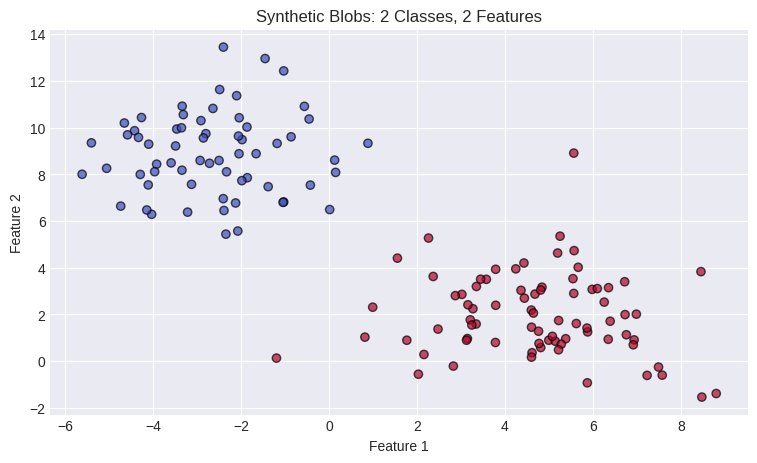

In [14]:
X_blob, y_blob = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=1.8, random_state=42)

X_blob_train, X_blob_val, y_blob_train, y_blob_val = train_test_split(
    X_blob, y_blob, test_size=0.3, random_state=42
)

plt.scatter(X_blob_train[:, 0], X_blob_train[:, 1], c=y_blob_train, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Blobs: 2 Classes, 2 Features')
plt.show()

### Implementing Logistic Regression from Scratch

Same structure as Part 1's linear regression gradient descent, with two changes: we pass the 
linear output through the sigmoid function, and the gradient formula (derived from the log 
loss cost function) turns out to have the exact same form as linear regression's gradient — 
only the definition of $\hat{y}$ changed.

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_gradient_descent(X, y, alpha=0.1, n_iters=1000):
    mu, sigma = X.mean(axis=0), X.std(axis=0)
    X_scaled = (X - mu) / sigma
    X_b = add_intercept(X_scaled)
    m, n = X_b.shape
    theta = np.zeros(n)
    cost_history = []

    for i in range(n_iters):
        z = X_b @ theta
        y_pred = sigmoid(z)
        error = y_pred - y
        gradient = (1/m) * (X_b.T @ error)
        theta -= alpha * gradient

        eps = 1e-10
        cost = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
        cost_history.append(cost)

    return theta, cost_history, mu, sigma

theta_log, cost_history_log, mu_log, sigma_log = logistic_gradient_descent(
    X_blob_train, y_blob_train, alpha=0.5, n_iters=1000
)

### Comparing with scikit-learn

As in Part 1, we confirm our from-scratch implementation agrees with sklearn's 
`LogisticRegression` by comparing predictions on the validation set, not raw parameter values 
(since ours are in scaled feature space).

In [16]:
log_sklearn = LogisticRegression()
log_sklearn.fit(X_blob_train, y_blob_train)

X_val_scaled = (X_blob_val - mu_log) / sigma_log
X_val_b = add_intercept(X_val_scaled)
y_pred_scratch = (sigmoid(X_val_b @ theta_log) >= 0.5).astype(int)
y_pred_sklearn = log_sklearn.predict(X_blob_val)

comparison = pd.DataFrame({
    'Model': ['From Scratch', 'sklearn'],
    'Validation Accuracy': [
        accuracy_score(y_blob_val, y_pred_scratch),
        accuracy_score(y_blob_val, y_pred_sklearn)
    ]
})
comparison

,Model,Validation Accuracy
0,From Scratch,1.0
1,sklearn,1.0


### Interactive: Decision Boundary & Threshold

Using the sklearn model, this plot shows the decision boundary directly on the 2D feature 
space, along with the probability gradient (background shading) so you can see how confident 
the model is in different regions, not just where the hard boundary sits.

**Try it:** move the threshold away from 0.5. Lowering it classifies more points as class 1 
(the boundary shifts to "make it easier" to be predicted class 1); raising it does the 
opposite. Watch how the boundary line itself shifts in response.

In [17]:
xx, yy = np.meshgrid(
    np.linspace(X_blob[:, 0].min() - 1, X_blob[:, 0].max() + 1, 300),
    np.linspace(X_blob[:, 1].min() - 1, X_blob[:, 1].max() + 1, 300)
)
grid_probs = log_sklearn.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

def plot_decision_boundary(threshold=0.5):
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, grid_probs, levels=50, cmap='coolwarm', alpha=0.4)
    plt.contour(xx, yy, grid_probs, levels=[threshold], colors='black', linewidths=2)
    plt.scatter(X_blob_train[:, 0], X_blob_train[:, 1], c=y_blob_train, cmap='coolwarm', edgecolors='k', alpha=0.8)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'Decision Boundary at Threshold = {threshold:.2f}')
    plt.colorbar(label='P(class = 1)')
    plt.show()

interact(plot_decision_boundary,
         threshold=widgets.FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05, description='Threshold'));

interactive(children=(FloatSlider(value=0.5, description='Threshold', max=0.95, min=0.05, step=0.05), Output()…

### Stage B: Breast Cancer Wisconsin (Real Data)

Now we move to a real, high-stakes dataset: 30 measured features from breast mass images, 
labeling each tumor as malignant or benign. Unlike the clean blobs, real features are 
correlated, noisier, and the classes aren't perfectly separable — a good contrast to Stage A. 
This is also where evaluation metrics beyond accuracy start to matter a lot, since 
misclassifying a malignant tumor as benign is far more costly than the reverse.

In [18]:
cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame
feature_names = list(cancer.feature_names)

X_cancer_train, X_cancer_val, y_cancer_train, y_cancer_val = train_test_split(
    df_cancer[feature_names], df_cancer['target'], test_size=0.3, random_state=42, stratify=df_cancer['target']
)

scaler_cancer = StandardScaler()
X_cancer_train_scaled = scaler_cancer.fit_transform(X_cancer_train)
X_cancer_val_scaled = scaler_cancer.transform(X_cancer_val)

log_cancer = LogisticRegression(max_iter=5000)
log_cancer.fit(X_cancer_train_scaled, y_cancer_train)

print(f"Validation accuracy: {accuracy_score(y_cancer_val, log_cancer.predict(X_cancer_val_scaled)):.4f}")

Validation accuracy: 0.9883


### Interactive: Explore Decision Boundaries Across Feature Pairs

Pick any two of the 30 features to see their decision boundary. Note this trains a *separate* 
2-feature model each time (not a slice of the full 30-feature model), purely to visualize how 
boundary shape and class separability change depending on which features you choose. Some pairs 
separate the classes cleanly; others overlap heavily — a good illustration of why using all 30 
features (rather than eyeballing 2) gives the real model much more to work with.

In [19]:
def plot_feature_pair_boundary(feature_x='mean radius', feature_y='mean texture'):
    X_pair = df_cancer[[feature_x, feature_y]].values
    y_pair = df_cancer['target'].values

    X_pair_train, X_pair_val, y_pair_train, y_pair_val = train_test_split(
        X_pair, y_pair, test_size=0.3, random_state=42, stratify=y_pair
    )

    scaler_pair = StandardScaler()
    X_pair_train_scaled = scaler_pair.fit_transform(X_pair_train)

    model_pair = LogisticRegression()
    model_pair.fit(X_pair_train_scaled, y_pair_train)

    xx_p, yy_p = np.meshgrid(
        np.linspace(X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1, 200),
        np.linspace(X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1, 200)
    )
    grid_scaled = scaler_pair.transform(np.c_[xx_p.ravel(), yy_p.ravel()])
    probs_p = model_pair.predict_proba(grid_scaled)[:, 1].reshape(xx_p.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx_p, yy_p, probs_p, levels=50, cmap='coolwarm', alpha=0.4)
    plt.contour(xx_p, yy_p, probs_p, levels=[0.5], colors='black', linewidths=2)
    plt.scatter(X_pair[:, 0], X_pair[:, 1], c=y_pair, cmap='coolwarm', edgecolors='k', alpha=0.6, s=20)
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.title(f'Decision Boundary: {feature_x} vs {feature_y}')
    plt.show()

interact(plot_feature_pair_boundary,
         feature_x=widgets.Dropdown(options=feature_names, value='mean radius', description='X feature'),
         feature_y=widgets.Dropdown(options=feature_names, value='mean texture', description='Y feature'));

interactive(children=(Dropdown(description='X feature', options=(np.str_('mean radius'), np.str_('mean texture…

### Interactive: Threshold, Confusion Matrix & Precision/Recall

Using the full 30-feature model, moving the threshold changes which predictions count as 
malignant (class 1) vs benign (class 0), which directly reshapes the confusion matrix.

- **Precision**: of everything predicted malignant, what fraction actually was? High precision 
  means fewer false alarms.
- **Recall**: of everything actually malignant, what fraction did we catch? High recall means 
  fewer missed cancers.

### How do you actually choose a threshold?

There's no universal "correct" threshold — it depends on the relative *cost* of the two kinds 
of mistakes a classifier can make:

- **False Positive** (predicting malignant when it's actually benign): the cost is typically 
  an unnecessary follow-up test, a biopsy, or a period of anxiety for the patient. Unpleasant, 
  but recoverable.
- **False Negative** (predicting benign when it's actually malignant): the cost is a missed 
  cancer diagnosis — the patient goes home believing they're healthy while the disease 
  progresses untreated. This is far harder to recover from, and in the worst case, fatal.

Because these two errors are **not equally costly**, optimizing for raw accuracy (which treats 
every mistake the same) is the wrong goal here. Instead, we deliberately accept more false 
positives in exchange for fewer false negatives — which means favoring **recall over precision**, 
which in turn means choosing a **lower threshold** than the default 0.5. A lower threshold makes 
it "easier" for the model to flag something as malignant, catching more true cases at the cost 
of more false alarms.

This is a judgment call, not a purely mathematical one — a doctor, not a data scientist alone, 
should ultimately decide where that line sits, informed by metrics like the ones below. But as 
the person building the model, it's your job to make sure that tradeoff is visible and 
adjustable, rather than silently baked in at threshold=0.5 by default.

**Try it below:** drag the threshold down from 0.5 and watch recall climb (fewer missed 
cancers) while precision drops (more false alarms) — and notice how few missed cancers remain 
even at a fairly low threshold, versus how many extra false alarms that costs.

In [20]:
val_probs = log_cancer.predict_proba(X_cancer_val_scaled)[:, 1]

def plot_threshold_confusion(threshold=0.5):
    preds = (val_probs >= threshold).astype(int)
    cm = confusion_matrix(y_cancer_val, preds)
    precision = precision_score(y_cancer_val, preds, zero_division=0)
    recall = recall_score(y_cancer_val, preds, zero_division=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Benign', 'Predicted Malignant'])
    ax.set_yticklabels(['Actual Benign', 'Actual Malignant'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)
    plt.title(f'Threshold={threshold:.2f} | Precision={precision:.3f} | Recall={recall:.3f}')
    plt.tight_layout()
    plt.show()

interact(plot_threshold_confusion,
         threshold=widgets.FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05, description='Threshold'));

interactive(children=(FloatSlider(value=0.5, description='Threshold', max=0.95, min=0.05, step=0.05), Output()…

### ROC Curve

The ROC curve plots recall (true positive rate) against the false positive rate across *every* 
possible threshold at once, giving a full picture of the tradeoff instead of one snapshot. The 
diagonal line represents random guessing; the closer the curve hugs the top-left corner, the 
better the model separates the classes. AUC (area under the curve) summarizes this into a 
single number — 1.0 is perfect, 0.5 is random.

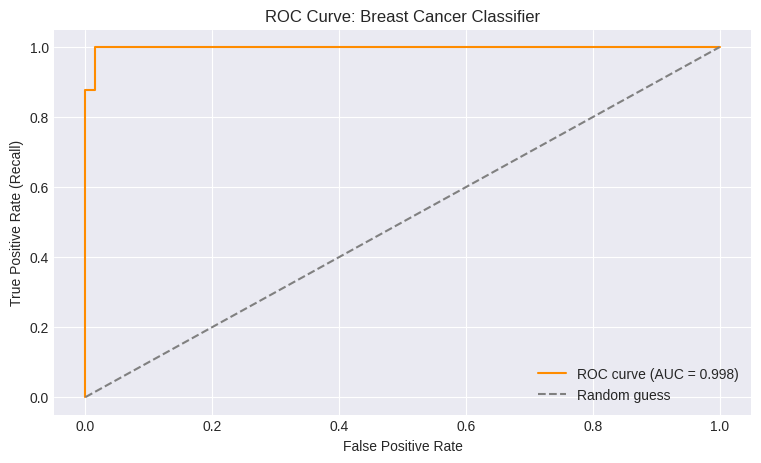

In [21]:
fpr, tpr, thresholds_roc = roc_curve(y_cancer_val, val_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Breast Cancer Classifier')
plt.legend()
plt.show()

> **Misconception check:** "Accuracy is the best way to evaluate a classifier."  
> Not always — especially with imbalanced classes or unequal error costs. A model that always 
> predicts "benign" could still score high accuracy if most cases in the dataset are benign, 
> while missing every actual cancer case. Precision, recall, and the ROC curve reveal this in 
> a way a single accuracy number cannot, which is exactly why we built the threshold widget 
> above instead of only reporting one accuracy score.

<a id="part5"></a>
## Part 5: Wrap-up

### Recap: When to Use What

| Model | Best For | Key Hyperparameter | Main Failure Mode |
|---|---|---|---|
| Linear Regression | Predicting a continuous value with a roughly linear relationship | Learning rate (α) for gradient descent | Underfits non-linear relationships |
| Polynomial Regression | Continuous value with a curved/non-linear relationship | Degree | Overfits at high degree, especially with little data |
| Ridge Regression | Reducing overfitting when you believe most features matter somewhat | α (λ) | Too high α underfits; doesn't zero out features |
| Lasso Regression | Reducing overfitting *and* wanting automatic feature selection | α (λ) | Can arbitrarily drop one of two correlated useful features |
| Logistic Regression | Binary classification with a roughly linear decision boundary | Threshold (for predictions), regularization strength (for training) | Struggles when classes aren't linearly separable |

The common thread across all five: every one of them is fundamentally about balancing 
**bias** (a model too simple to capture the pattern) against **variance** (a model so 
flexible it captures noise instead of signal) — whether that knob is polynomial degree, 
regularization strength, or feature choice.

### Quick Check: Which Model Would You Use?

Five short scenarios. Pick an answer from each dropdown, then run the cell to reveal the 
reasoning. There's no scoring here — this is meant to test your intuition, not your memory.

In [22]:
quiz_questions = [
    {
        "scenario": "You have 10,000 features but only 50 training samples, and you suspect most features are irrelevant.",
        "options": ["Plain Linear Regression", "Ridge Regression", "Lasso Regression"],
        "answer": "Lasso Regression",
        "explanation": "With far more features than samples and a belief that most are irrelevant, Lasso's ability to zero out coefficients performs automatic feature selection — Ridge would keep all 10,000 features with small weights, which is harder to interpret and doesn't reduce the effective model complexity as much."
    },
    {
        "scenario": "Your polynomial regression model has very low training error but very high validation error.",
        "options": ["Increase the polynomial degree", "Decrease the polynomial degree or add regularization", "Collect more features"],
        "answer": "Decrease the polynomial degree or add regularization",
        "explanation": "Low training error with high validation error is the signature of overfitting (high variance). The fix is to reduce model complexity (lower degree) or constrain it (regularization) — increasing degree would make overfitting worse, and more features doesn't address variance."
    },
    {
        "scenario": "Both your training and validation error are high and close to each other.",
        "options": ["This is overfitting — add regularization", "This is underfitting — increase model complexity", "This is a good fit — ship it"],
        "answer": "This is underfitting — increase model complexity",
        "explanation": "High error on both sets (not a big gap between them) means the model is too simple to capture the pattern at all — this is underfitting (high bias). Regularization would only make this worse by constraining the model further."
    },
    {
        "scenario": "You're building a spam filter and users are more annoyed by false positives (real emails marked as spam) than by the occasional spam email getting through.",
        "options": ["Raise the classification threshold", "Lower the classification threshold", "Threshold doesn't matter here"],
        "answer": "Raise the classification threshold",
        "explanation": "Raising the threshold makes the model more conservative about predicting 'spam,' which reduces false positives (real emails wrongly flagged) at the cost of letting more actual spam through — the opposite tradeoff from the cancer screening case, because here the false positive is the costlier error."
    },
    {
        "scenario": "You need to predict a binary outcome, and when you plot the two classes, they form two clearly separated circular clusters.",
        "options": ["Logistic Regression will work well as-is", "Logistic Regression will struggle — decision boundary is linear", "Linear Regression is the right choice"],
        "answer": "Logistic Regression will struggle — decision boundary is linear",
        "explanation": "Plain logistic regression produces a straight-line (or hyperplane) decision boundary. If the true separation between classes is circular/non-linear, it can't be captured without adding polynomial features (similar to Part 2) or using a fundamentally different model."
    }
]

q_selector = widgets.Dropdown(
    options=[(f"Question {i+1}", i) for i in range(5)],
    description='Question'
)
answer_selector = widgets.Dropdown(
    options=['—'] + quiz_questions[0]['options'],
    description='Your answer'
)

def update_answer_options(change):
    q_idx = change['new']
    answer_selector.options = ['—'] + quiz_questions[q_idx]['options']
    answer_selector.value = '—'

q_selector.observe(update_answer_options, names='value')

def run_quiz(q_num, your_answer):
    q = quiz_questions[q_num]
    print(f"Scenario: {q['scenario']}\n")
    if your_answer == '—':
        print("Select an answer from the dropdown above.")
        return
    correct = your_answer == q['answer']
    print(f"Your answer: {your_answer}")
    print(f"Correct answer: {q['answer']}")
    print(f"{'Correct!' if correct else 'Not quite.'}\n")
    print(f"Why: {q['explanation']}")

interact(run_quiz, q_num=q_selector, your_answer=answer_selector);

interactive(children=(Dropdown(description='Question', options=(('Question 1', 0), ('Question 2', 1), ('Questi…

## What's Next

This notebook covered the foundations of supervised learning: linear and polynomial 
regression, logistic regression, and the bias-variance tradeoff that regularization exists 
to manage. A natural next step from here is **neural networks** — which can be thought of as 
stacking many logistic-regression-like units together, letting the model learn non-linear 
decision boundaries and feature combinations automatically instead of hand-picking polynomial 
degrees or feature pairs. Along with that comes new regularization tools (dropout, batch 
normalization) that address the same underfitting/overfitting tradeoff explored here, just 
in a more flexible model.

If you found the interactive widgets useful, try changing the datasets in Parts 1 and 4 to 
your own data — the same functions should work with minimal changes as long as the shapes 
match.